## About this notebook
This notebook is the data analysis for my project on laugh tracks.

### A brief history of laugh tracks
This project goes into the timeline of laugh track usage in sitcoms over time. The origin of the laugh track can be traced back to use in radio with Bing Crosby's radio show (1949 - 1952). It was popularized for television in 1953 with Charles Douglass' "laff box" and was transformed once more in the 1980s with the advent of stereophonic laugh tracks. (Source: https://daily.jstor.org/the-laugh-track-loathe-it-or-love-it/)

### The data for this project
The focus of this project is the use of laugh tracks in situational comedies (sitcoms) on broadcast television since the 1950s.

The data collection process in detail is located in 'tv_laugh_tracks_data_collection_ipynb'.

Witht this notebook, the data includes:
- A .csv file with:
    - Every comedy that appeared in the Nielsen top-rated television programs based on U.S. viewereship (source: https://en.wikipedia.org/wiki/Top-rated_United_States_television_programs_by_season)
    - The camera style of the show (single vs. multi-cam), if known.
    - The year in wchich the season aired
    - The show title, show network
    - Whether the show utilizing a studio audience, a canned laugh track, or no added laughter (these were categorized using GPT 5. Categorization was validated against a hand-coded ground truth sample of 90 shows (representing 10% of the dataset), achieving 88% accuracy.)


In [43]:
import pandas as pd
import re
import numpy as np



In [44]:
df_complete_data = pd.read_csv('/Users/rachelvice/Development/Lede/Projects/laugh_tracks/data/top_rated_comedies_1950_2025_classified.csv')

In [45]:
df_complete_data_clean = df_complete_data.drop(columns=['wikilink', 'show_id', 'overview'])

In [46]:
df_complete_data_clean.head()

,year,rank,title,network,rating,genre_id,genre,camera,laugh_track_category
0,1950,1,Texaco Star Theater,NBC,61.6,35,comedy,Unknown,studio_audience
1,1950,4,Your Show of Shows,NBC,42.6,35,comedy,Multi-camera,studio_audience
2,1950,5,The Colgate Comedy Hour,NBC,42.0,35,comedy,Multi-camera,studio_audience
3,1950,8,Arthur Godfrey's Talent Scouts,CBS,40.6,35,comedy,Multi-camera,studio_audience
4,1950,10,Mama,CBS,39.7,35,comedy,Unknown,no_added_laughter


In [76]:
df_single_cam = df_complete_data_clean[df_complete_data_clean['camera'] == 'Single-camera'].sort_values(by='rating',ascending=False)
df_single_cam

,year,rank,title,network,rating,genre_id,genre,camera,laugh_track_category
176,1963,1,The Beverly Hillbillies,CBS,39.1,"3,510,751",comedy,Single-camera,canned_laugh_track
161,1962,1,The Beverly Hillbillies,CBS,36.0,"3,510,751",comedy,Single-camera,canned_laugh_track
198,1964,2,Bewitched,ABC,31.0,"10765,35,10751,18",comedy,Single-camera,canned_laugh_track
178,1963,4,Petticoat Junction,CBS,30.3,"3,510,751",comedy,Single-camera,canned_laugh_track
118,1958,8,The Real McCoys,ABC,30.1,35,comedy,Single-camera,canned_laugh_track
...,...,...,...,...,...,...,...,...,...
854,2014,23,Modern Family,ABC,7.5,35,comedy,Single-camera,no_added_laughter
830,2010,17,Desperate Housewives,ABC,7.5,"9648,18,35",comedy,Single-camera,no_added_laughter
833,2010,25,Modern Family,ABC,7.1,35,comedy,Single-camera,no_added_laughter
840,2011,28,Desperate Housewives,ABC,7.0,"9648,18,35",comedy,Single-camera,no_added_laughter


In [80]:
df_canned = df_complete_data_clean[df_complete_data_clean['laugh_track_category'] == 'canned_laugh_track']
df_canned.sort_values(by='rank')

,year,rank,title,network,rating,genre_id,genre,camera,laugh_track_category
286,1969,1,Rowan & Martin's Laugh-In,NBC,26.3,35,comedy,Unknown,canned_laugh_track
252,1967,1,The Andy Griffith Show,CBS,27.6,"3,510,751",comedy,Single-camera,canned_laugh_track
268,1968,1,Rowan & Martin's Laugh-In,NBC,31.8,35,comedy,Unknown,canned_laugh_track
176,1963,1,The Beverly Hillbillies,CBS,39.1,"3,510,751",comedy,Single-camera,canned_laugh_track
161,1962,1,The Beverly Hillbillies,CBS,36.0,"3,510,751",comedy,Single-camera,canned_laugh_track
...,...,...,...,...,...,...,...,...,...
251,1966,29,My Three Sons,CBS,20.2,"3,510,751",comedy,Unknown,canned_laugh_track
285,1968,30,The Doris Day Show,CBS,20.4,"35,37",comedy,Unknown,canned_laugh_track
115,1957,30,The Real McCoys,ABC,26.6,35,comedy,Single-camera,canned_laugh_track
175,1962,30,The Flintstones,ABC,20.5,"10751,16,35",comedy,Unknown,canned_laugh_track


In [86]:
df_studio = df_complete_data_clean[df_complete_data_clean['laugh_track_category'] == 'studio_audience']
df_studio.sort_values(by='rank').head(15)

,year,rank,title,network,rating,genre_id,genre,camera,laugh_track_category
0,1950,1,Texaco Star Theater,NBC,61.6,35,comedy,Unknown,studio_audience
679,1994,1,Seinfeld,NBC,20.6,35,comedy,Multi-camera,studio_audience
531,1986,1,The Cosby Show,NBC,34.9,"3,510,751",comedy,Multi-camera,studio_audience
336,1973,1,All in the Family,CBS,31.2,35,comedy,Unknown,studio_audience
547,1987,1,The Cosby Show,NBC,27.8,"3,510,751",comedy,Multi-camera,studio_audience
55,1954,1,I Love Lucy,CBS,49.3,"3,510,751",comedy,Multi-camera,studio_audience
411,1978,1,Laverne & Shirley,ABC,30.5,"3,510,751",comedy,Unknown,studio_audience
347,1974,1,All in the Family,CBS,30.2,35,comedy,Unknown,studio_audience
775,2001,1,Friends,NBC,15.0,35,comedy,Multi-camera,studio_audience
88,1956,1,I Love Lucy,CBS,43.7,"3,510,751",comedy,Multi-camera,studio_audience


In [88]:
df_silence = df_complete_data_clean[df_complete_data_clean['laugh_track_category'] == 'no_added_laughter']
df_silence.sort_values(by='rank').head(15)

,year,rank,title,network,rating,genre_id,genre,camera,laugh_track_category
453,1980,2,The Dukes of Hazzard,CBS,27.30,"10759,18,35,80",comedy,Single-camera,no_added_laughter
90,1956,3,General Electric Theater,CBS,36.90,"35,18",comedy,Unknown,no_added_laughter
804,2004,4,Desperate Housewives,ABC,14.50,"9648,18,35",comedy,Single-camera,no_added_laughter
808,2005,4,Desperate Housewives,ABC,13.80,"9648,18,35",comedy,Single-camera,no_added_laughter
890,2022,4,Young Sheldon,CBS,9.28,"35,10751,18",comedy,Single-camera,no_added_laughter
873,2018,4,Young Sheldon,CBS,8.70,"35,10751,18",comedy,Single-camera,no_added_laughter
853,2014,4,NCIS: New Orleans,CBS,11.30,"10759,18,35",comedy,Multi-camera,no_added_laughter
495,1983,4,The A-Team,NBC,24.00,"10759,35,80",comedy,Unknown,no_added_laughter
862,2016,4,Bull,CBS,9.60,"80,18,35",comedy,Unknown,no_added_laughter
902,2024,5,Ghosts,CBS,12.10,"3,510,765",comedy,Unknown,no_added_laughter


In [48]:
df_category_by_year = df_complete_data_clean.groupby(['year', 'laugh_track_category']).size().reset_index(name='count')
df_category_by_year

,year,laugh_track_category,count
0,1950,no_added_laughter,3
1,1950,studio_audience,8
2,1951,canned_laugh_track,1
3,1951,no_added_laughter,2
4,1951,studio_audience,9
...,...,...,...
170,2022,no_added_laughter,4
171,2022,studio_audience,2
172,2023,no_added_laughter,5
173,2024,no_added_laughter,5


In [49]:
df_comedies_by_year = df_complete_data_clean.groupby('year').size().reset_index(name='total_comedies')
df_comedies_by_year

,year,total_comedies
0,1950,11
1,1951,12
2,1952,15
3,1953,17
4,1954,17
...,...,...
70,2020,4
71,2021,3
72,2022,6
73,2023,5


<Axes: xlabel='year'>

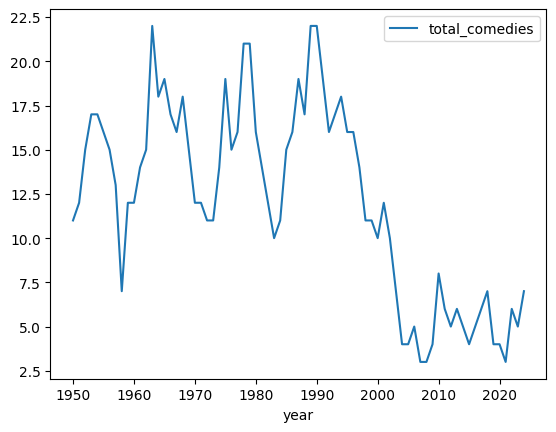

In [50]:
df_comedies_by_year.plot.line(x='year')

In [51]:
df_category_by_year = df_category_by_year.merge(df_comedies_by_year, on='year')
df_category_by_year

,year,laugh_track_category,count,total_comedies
0,1950,no_added_laughter,3,11
1,1950,studio_audience,8,11
2,1951,canned_laugh_track,1,12
3,1951,no_added_laughter,2,12
4,1951,studio_audience,9,12
...,...,...,...,...
170,2022,no_added_laughter,4,6
171,2022,studio_audience,2,6
172,2023,no_added_laughter,5,5
173,2024,no_added_laughter,5,7


In [52]:
df_category_by_year['as_percentage'] = round(df_category_by_year['count']/df_category_by_year['total_comedies'] * 100)
df_category_by_year

,year,laugh_track_category,count,total_comedies,as_percentage
0,1950,no_added_laughter,3,11,27.0
1,1950,studio_audience,8,11,73.0
2,1951,canned_laugh_track,1,12,8.0
3,1951,no_added_laughter,2,12,17.0
4,1951,studio_audience,9,12,75.0
...,...,...,...,...,...
170,2022,no_added_laughter,4,6,67.0
171,2022,studio_audience,2,6,33.0
172,2023,no_added_laughter,5,5,100.0
173,2024,no_added_laughter,5,7,71.0


<Axes: xlabel='year'>

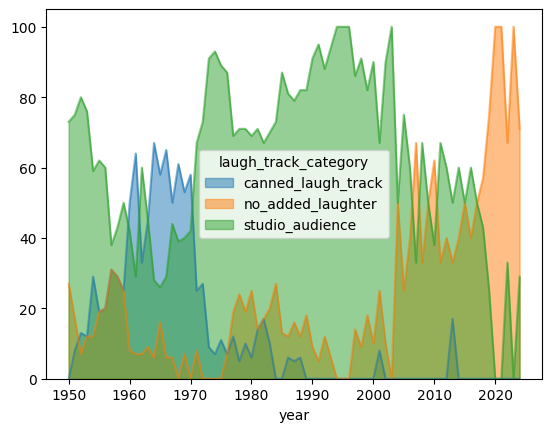

In [53]:
pivot = df_category_by_year.pivot(index='year', columns='laugh_track_category', values = 'as_percentage')
pivot.plot.area(stacked=False)


In [54]:
#filling in NaN with 0

pivot = pivot.fillna(0)
pivot.head()
pivot.to_csv('percentage_laugh_track_cat_per_year.csv')

In [55]:
pivot.melt()

,laugh_track_category,value
0,canned_laugh_track,0.0
1,canned_laugh_track,8.0
2,canned_laugh_track,13.0
3,canned_laugh_track,12.0
4,canned_laugh_track,29.0
...,...,...
220,studio_audience,0.0
221,studio_audience,0.0
222,studio_audience,33.0
223,studio_audience,0.0


In [56]:
df_for_linecharts = df_category_by_year.drop(columns=['count', 'total_comedies'])
df_for_linecharts

,year,laugh_track_category,as_percentage
0,1950,no_added_laughter,27.0
1,1950,studio_audience,73.0
2,1951,canned_laugh_track,8.0
3,1951,no_added_laughter,17.0
4,1951,studio_audience,75.0
...,...,...,...
170,2022,no_added_laughter,67.0
171,2022,studio_audience,33.0
172,2023,no_added_laughter,100.0
173,2024,no_added_laughter,71.0


In [57]:
#what year did "no laughter added" start to dominate
pivot['no_added_laughter'].tail(25)

year
2000     10.0
2001     25.0
2002     10.0
2003      0.0
2004     50.0
2005     25.0
2006     40.0
2007     67.0
2008     33.0
2009     50.0
2010     62.0
2011     33.0
2012     40.0
2013     33.0
2014     40.0
2015     50.0
2016     40.0
2017     50.0
2018     57.0
2019     75.0
2020    100.0
2021    100.0
2022     67.0
2023    100.0
2024     71.0
Name: no_added_laughter, dtype: float64

<Axes: xlabel='year'>

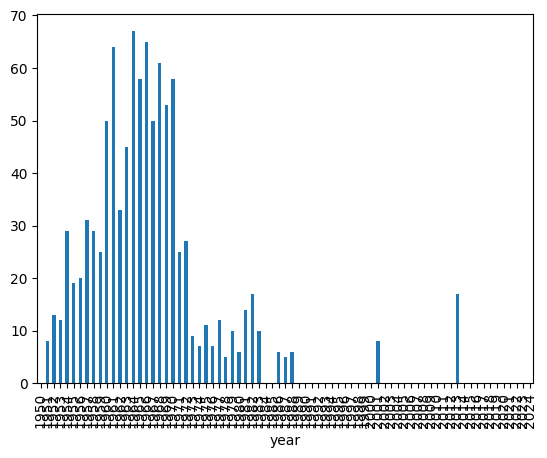

In [58]:
pivot['canned_laugh_track'].plot.bar()

<Axes: xlabel='year'>

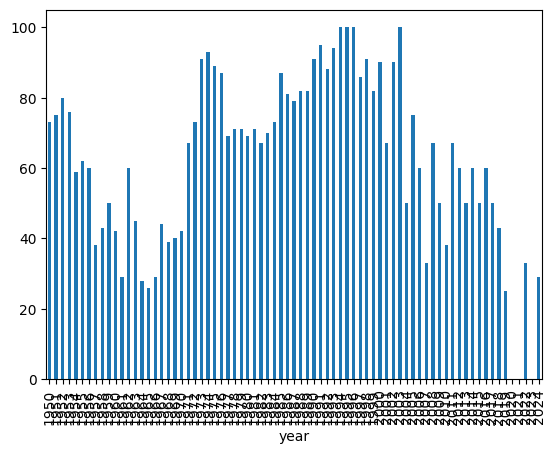

In [59]:
pivot['studio_audience'].plot.bar()

<Axes: xlabel='year'>

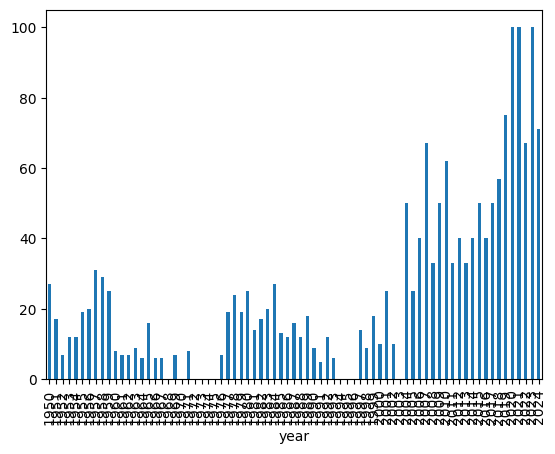

In [60]:
pivot['no_added_laughter'].plot.bar()

In [61]:
#when did canned laughter peak?
pivot['canned_laugh_track'].idxmax()

np.int64(1964)

In [62]:
#what about studio audiences
pivot['studio_audience'].idxmax()

np.int64(1994)

In [63]:
#no laughter added
pivot['no_added_laughter'].idxmax()

np.int64(2020)

In [64]:
df_comedy_per_year = round((df_complete_data_clean.groupby('year').size())/30 * 100).to_frame()
df_comedy_per_year.to_csv('comedies_per_year_%.csv')

In [65]:
df_comedy_per_year = pd.read_csv('comedies_per_year_%.csv')
df_comedy_per_year

,year,0
0,1950,37.0
1,1951,40.0
2,1952,50.0
3,1953,57.0
4,1954,57.0
...,...,...
70,2020,13.0
71,2021,10.0
72,2022,20.0
73,2023,17.0


In [66]:
df_laugh_track_cat_count = df_complete_data_clean['laugh_track_category'].value_counts().to_frame()
df_laugh_track_cat_count

,count
laugh_track_category,
studio_audience,607
no_added_laughter,151
canned_laugh_track,150


In [67]:
df_comedies_by_year.head()

,year,total_comedies
0,1950,11
1,1951,12
2,1952,15
3,1953,17
4,1954,17


In [68]:
df_laugh_cat_by_year = df_complete_data_clean.groupby(['year', 'laugh_track_category']).size()

In [69]:
df_laugh_cat_by_year_for_area_chart = df_laugh_cat_by_year.reset_index(name='count')
df_laugh_cat_by_year_for_area_chart

,year,laugh_track_category,count
0,1950,no_added_laughter,3
1,1950,studio_audience,8
2,1951,canned_laugh_track,1
3,1951,no_added_laughter,2
4,1951,studio_audience,9
...,...,...,...
170,2022,no_added_laughter,4
171,2022,studio_audience,2
172,2023,no_added_laughter,5
173,2024,no_added_laughter,5


<Axes: xlabel='year'>

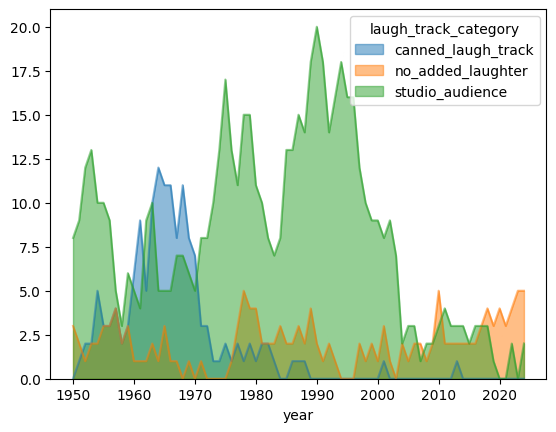

In [70]:
df_laugh_cat_by_year.unstack().plot(kind='area', stacked=False)

In [71]:
df_complete_data_clean.head()

,year,rank,title,network,rating,genre_id,genre,camera,laugh_track_category
0,1950,1,Texaco Star Theater,NBC,61.6,35,comedy,Unknown,studio_audience
1,1950,4,Your Show of Shows,NBC,42.6,35,comedy,Multi-camera,studio_audience
2,1950,5,The Colgate Comedy Hour,NBC,42.0,35,comedy,Multi-camera,studio_audience
3,1950,8,Arthur Godfrey's Talent Scouts,CBS,40.6,35,comedy,Multi-camera,studio_audience
4,1950,10,Mama,CBS,39.7,35,comedy,Unknown,no_added_laughter


In [72]:
df_for_beeswarm = df_complete_data_clean.drop(columns=['genre_id','genre'])

In [73]:
df_for_beeswarm.head()

,year,rank,title,network,rating,camera,laugh_track_category
0,1950,1,Texaco Star Theater,NBC,61.6,Unknown,studio_audience
1,1950,4,Your Show of Shows,NBC,42.6,Multi-camera,studio_audience
2,1950,5,The Colgate Comedy Hour,NBC,42.0,Multi-camera,studio_audience
3,1950,8,Arthur Godfrey's Talent Scouts,CBS,40.6,Multi-camera,studio_audience
4,1950,10,Mama,CBS,39.7,Unknown,no_added_laughter


In [74]:
df_for_beeswarm.dtypes

year                      int64
rank                      int64
title                       str
network                     str
rating                  float64
camera                      str
laugh_track_category        str
dtype: object

In [75]:
df_for_beeswarm.to_json('show_data_for_beeswarm.json')